In [1]:
from google.colab import drive # Google Drive Connect with Colab
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive # Drive ke MyDrive folder me files dekhne ke liye

'Colab Notebooks'   PlantVillage-Dataset.zip


In [3]:
# ZIP File Unzip
!unzip "/content/drive/MyDrive/PlantVillage-Dataset.zip" -d "/content/drive/MyDrive/PlantVillage"


Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/PlantVillage/PlantVillage-Dataset/Raw/color/Wheat_Mildew/mildew_327.png  
  inflating: /content/drive/MyDrive/PlantVillage/PlantVillage-Dataset/Raw/color/Wheat_Mildew/mildew_328.png  
  inflating: /content/drive/MyDrive/PlantVillage/PlantVillage-Dataset/Raw/color/Wheat_Mildew/mildew_329.png  
  inflating: /content/drive/MyDrive/PlantVillage/PlantVillage-Dataset/Raw/color/Wheat_Mildew/mildew_33.png  
  inflating: /content/drive/MyDrive/PlantVillage/PlantVillage-Dataset/Raw/color/Wheat_Mildew/mildew_330.png  
  inflating: /content/drive/MyDrive/PlantVillage/PlantVillage-Dataset/Raw/color/Wheat_Mildew/mildew_331.png  
  inflating: /content/drive/MyDrive/PlantVillage/PlantVillage-Dataset/Raw/color/Wheat_Mildew/mildew_332.png  
  inflating: /content/drive/MyDrive/PlantVillage/PlantVillage-Dataset/Raw/color/Wheat_Mildew/mildew_333.png  
  inflating: /content/drive/MyDrive/PlantVillage/PlantVillage-Dataset/

In [ ]:
# for checking available disease classes in PlantVillage folder
!ls "/content/drive/MyDrive/PlantVillage"

PlantVillage-Dataset


In [5]:
# Actual images folder ka path set karta hai
data_path = "/content/drive/MyDrive/PlantVillage/PlantVillage-Dataset/Raw/color"

In [ ]:
# for classes verify in folder
import os
print(os.listdir(data_path))  # disease names dikhenge


['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'PESGL_DRECRO_exserohilum_rostratum', 'PESGL_healthy_leaves', 'PESGL_MOESBU_smut', 'PESGL_SCLPGR_Sclerospora_graminicola', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Raspberry___healthy', 'Rice_Blast', 'Rice_Healthy', 'Rice_Insect', 'Rice_Leaffolder', 'Rice_Leaf_Scald', 'Rice_Stripes', 'Rice_Tungro', 'Rice_wali', 'Soybean___healthy', 'Squash___Powdery_mildew',

In [7]:
# Image preprocessing + Train/Validation split

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(data_path, target_size=(224,224),
                                         batch_size=32, class_mode='categorical',
                                         subset='training')

val_data = datagen.flow_from_directory(data_path, target_size=(224,224),
                                       batch_size=32, class_mode='categorical',
                                       subset='validation')


Found 61706 images belonging to 76 classes.
Found 15395 images belonging to 76 classes.


In [10]:
# CNN Model Creation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(76, activation='softmax')   # 76 classes
])

In [11]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
# Train Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 863s 443ms/step - accuracy: 0.3543 - loss: 2.6223 - val_accuracy: 0.6768 - val_loss: 1.1285
Epoch 2/10
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 799s 414ms/step - accuracy: 0.6394 - loss: 1.2137 - val_accuracy: 0.7254 - val_loss: 0.9278
Epoch 3/10
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 777s 403ms/step - accuracy: 0.7109 - loss: 0.9505 - val_accuracy: 0.7519 - val_loss: 0.8980
Epoch 4/10
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 765s 396ms/step - accuracy: 0.7577 - loss: 0.7707 - val_accuracy: 0.7660 - val_loss: 0.8597
Epoch 5/10
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 752s 390ms/step - accuracy: 0.7945 - loss: 0.6484 - val_accuracy: 0.7836 - val_loss: 0.8379
Epoch 6/10
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 756s 392ms/step - accuracy: 0.8169 - loss: 0.5657 - val_accuracy: 0.7661 - val_loss: 0.8631
Epoch 7/10
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 2856s 1s/step - accuracy: 0.8362 - loss: 0.5052 - val_accuracy: 0.7931 - val_loss: 0.8060
Epoch 8/10
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 659s 341ms/step - accu

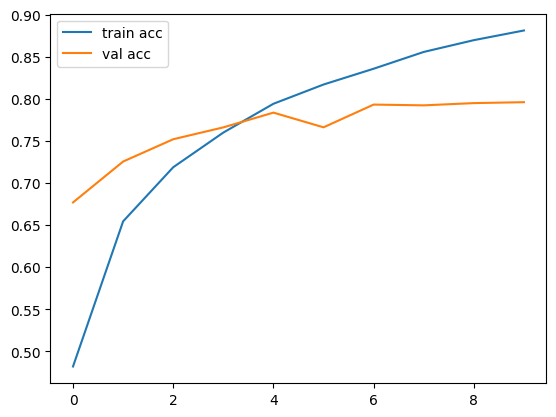

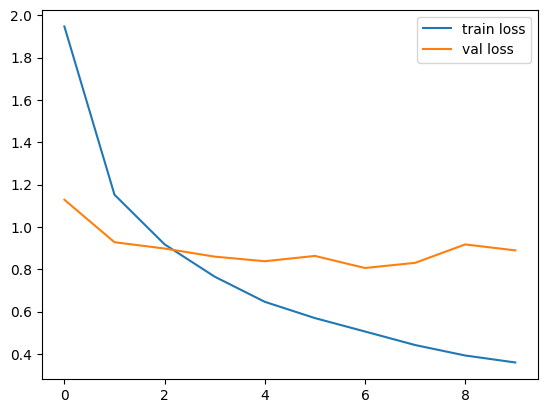

In [13]:
# Model Evaluation
# for Accuracy or loss plot kar
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

In [15]:
# Save Trained Model
model.save("/content/drive/MyDrive/crop_disease_model.h5")

In [16]:
# Load Trained Model (Future Use)
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/crop_disease_model.h5")